In [ ]:
# PROYECTO:
# SISTEMA INTELIGENTE DE DETECCIÓN DE FRAUDE FINANCIERO

# NOTEBOOK:
# 04_predicciones_sql.ipynb

# OBJETIVO:
# Generar predicciones de fraude utilizando el modelo
# entrenado previamente y almacenar los resultados
# en SQL Server para su posterior análisis en Power BI.

In [1]:
# Importación de librerías

import pandas as pd
import numpy as np

from sqlalchemy import create_engine

import pyodbc

In [2]:
# Conexión SQL Server

server = 'DARIELPC'
database = 'FraudAnalyticsDB'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

print("Conexión realizada correctamente.")

Conexión realizada correctamente.


In [3]:
# Cargar datos desde SQL Server

query = """
SELECT *
FROM transacciones_financieras
"""

df = pd.read_sql(query, engine)

df.head()

,id_transaccion,id_cliente,fecha_transaccion,monto_transaccion,tipo_transaccion,metodo_pago,moneda,pais_origen,ciudad_origen,ip_dispositivo,dispositivo_nuevo,intentos_fallidos,transacciones_24h,promedio_historico_cliente,desviacion_monto,pais_alto_riesgo,transaccion_fuera_horario,multiples_ips,fraude
0,1,49,2026-03-31 03:25:00,331758.10,Transferencia,ACH,DOP,República Dominicana,East Linda,119.119.99.54,True,5,9,158342.63,886240.10,False,True,False,False
1,2,315,2025-09-14 08:55:39,750818.86,Retiro,Transferencia Bancaria,DOP,República Dominicana,Cordovamouth,70.127.214.252,False,5,16,432794.73,680492.07,False,False,True,False
2,3,400,2025-07-11 00:03:28,1393581.51,Pago,Tarjeta,DOP,República Dominicana,North Jennifermouth,135.144.10.93,True,2,10,392279.28,442310.53,False,False,False,False
3,4,167,2025-06-29 07:54:40,2972052.48,Pago,Transferencia Bancaria,DOP,República Dominicana,North Elaineshire,179.42.64.18,True,0,17,122161.76,796999.65,False,False,True,False
4,5,241,2026-02-01 05:13:17,3324620.87,Compra,Transferencia Bancaria,DOP,República Dominicana,Stephenport,12.125.69.63,False,2,1,178966.73,55263.63,False,False,False,False


In [4]:
# Variables predictoras utilizadas por el modelo

X = df[[
    'monto_transaccion',
    'dispositivo_nuevo',
    'intentos_fallidos',
    'transacciones_24h',
    'promedio_historico_cliente',
    'desviacion_monto',
    'pais_alto_riesgo',
    'transaccion_fuera_horario',
    'multiples_ips'
]]

In [6]:
# Cargar modelo entrenado

import joblib

modelo = joblib.load(
    'modelo_fraude.pkl'
)

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [7]:
# Generación de predicciones

predicciones = modelo.predict(X)

predicciones[:10]

array([False, False, False, False, False, False,  True, False, False,
       False])

In [8]:
# Generación de probabilidades de fraude

probabilidades = modelo.predict_proba(X)

probabilidades[:5]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [9]:
# Extraer solamente la probabilidad de fraude

probabilidad_fraude = probabilidades[:,1]

probabilidad_fraude[:10]

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.01, 0.  ])

In [10]:
# Crear DataFrame con resultados finales

df_predicciones = pd.DataFrame({

    'id_transaccion': df['id_transaccion'],

    'fraude_predicho': predicciones,

    'probabilidad_fraude': probabilidad_fraude

})

df_predicciones.head()

,id_transaccion,fraude_predicho,probabilidad_fraude
0,1,False,0.0
1,2,False,0.0
2,3,False,0.0
3,4,False,0.0
4,5,False,0.0


In [12]:
# Convertir probabilidad a porcentaje

df_predicciones['probabilidad_fraude'] = (
    df_predicciones['probabilidad_fraude'] * 100
).round(2)

df_predicciones.tail()

,id_transaccion,fraude_predicho,probabilidad_fraude
14995,14996,True,10000.0
14996,14997,True,9800.0
14997,14998,False,0.0
14998,14999,False,0.0
14999,15000,False,0.0


In [13]:
# Clasificación de nivel de riesgo

def clasificar_riesgo(probabilidad):

    if probabilidad >= 80:
        return 'Alto'

    elif probabilidad >= 50:
        return 'Medio'

    else:
        return 'Bajo'

In [19]:
# Aplicar clasificación de riesgo

df_predicciones['nivel_riesgo'] = (
    df_predicciones['probabilidad_fraude']
    .apply(clasificar_riesgo)
)

df_predicciones.tail()

,id_transaccion,fraude_predicho,probabilidad_fraude,nivel_riesgo
14995,14996,True,10000.0,Alto
14996,14997,True,9800.0,Alto
14997,14998,False,0.0,Bajo
14998,14999,False,0.0,Bajo
14999,15000,False,0.0,Bajo


In [20]:
# Validar distribución de niveles de riesgo

df_predicciones['nivel_riesgo'].value_counts()

nivel_riesgo
Bajo    9186
Alto    5814
Name: count, dtype: int64

In [31]:
df_predicciones['probabilidad_fraude'] = (
    df_predicciones['probabilidad_fraude']
).round(4)

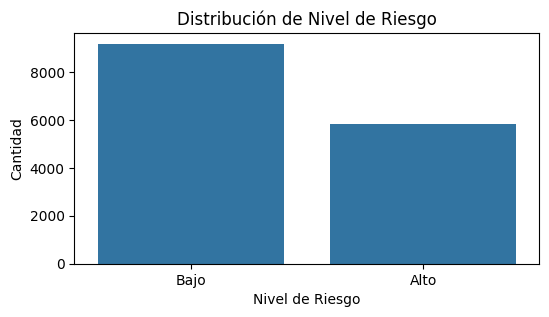

In [32]:
# Visualización de niveles de riesgo

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,3))

sns.countplot(
    x='nivel_riesgo',
    data=df_predicciones
)

plt.title('Distribución de Nivel de Riesgo')

plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad')

plt.show()

In [34]:
# Crear tabla final combinando información original
# con predicciones del modelo

df_final = df.merge(

    df_predicciones,

    on='id_transaccion',

    how='left'
)

df_final.tail()

,id_transaccion,id_cliente,fecha_transaccion,monto_transaccion,tipo_transaccion,metodo_pago,moneda,pais_origen,ciudad_origen,ip_dispositivo,...,transacciones_24h,promedio_historico_cliente,desviacion_monto,pais_alto_riesgo,transaccion_fuera_horario,multiples_ips,fraude,fraude_predicho,probabilidad_fraude,nivel_riesgo
14995,14996,405,2026-02-26 13:34:43,890274.38,Compra,ACH,DOP,Rusia,West Jeffreymouth,207.3.66.63,...,1,76430.66,850033.02,True,True,True,True,True,10000.0,Alto
14996,14997,8,2026-02-03 13:25:01,660612.61,Retiro,ACH,DOP,Rusia,Gillfurt,3.218.7.219,...,8,31465.12,697509.33,True,True,False,True,True,9800.0,Alto
14997,14998,293,2025-06-03 03:24:53,1931029.88,Retiro,Cheque,DOP,República Dominicana,Alexanderstad,50.44.243.4,...,1,442801.82,848204.20,False,False,True,False,False,0.0,Bajo
14998,14999,321,2026-03-31 06:19:05,4610959.52,Compra,Transferencia Bancaria,DOP,República Dominicana,Lake Codybury,109.43.40.249,...,12,148822.36,974049.45,False,False,False,False,False,0.0,Bajo
14999,15000,467,2025-10-09 03:25:24,3912743.74,Compra,Tarjeta,DOP,Rusia,Gonzalezside,45.115.42.122,...,16,408221.57,904131.09,True,False,True,False,False,0.0,Bajo


In [27]:
# Visualizar estructura final

df_final.columns

Index(['id_transaccion', 'id_cliente', 'fecha_transaccion',
       'monto_transaccion', 'tipo_transaccion', 'metodo_pago', 'moneda',
       'pais_origen', 'ciudad_origen', 'ip_dispositivo', 'dispositivo_nuevo',
       'intentos_fallidos', 'transacciones_24h', 'promedio_historico_cliente',
       'desviacion_monto', 'pais_alto_riesgo', 'transaccion_fuera_horario',
       'multiples_ips', 'fraude', 'fraude_predicho', 'probabilidad_fraude',
       'nivel_riesgo'],
      dtype='object')

In [35]:
# Guardar resultados en SQL Server

df_final.to_sql(

    'predicciones_fraude',

    engine,

    if_exists='replace',

    index=False
)

print("Tabla predicciones_fraude creada correctamente.")

Tabla predicciones_fraude creada correctamente.


In [36]:
# Validación final desde SQL Server

query_validacion = """
SELECT TOP 10 *
FROM predicciones_fraude
"""

validacion = pd.read_sql(
    query_validacion,
    engine
)

validacion

,id_transaccion,id_cliente,fecha_transaccion,monto_transaccion,tipo_transaccion,metodo_pago,moneda,pais_origen,ciudad_origen,ip_dispositivo,...,transacciones_24h,promedio_historico_cliente,desviacion_monto,pais_alto_riesgo,transaccion_fuera_horario,multiples_ips,fraude,fraude_predicho,probabilidad_fraude,nivel_riesgo
0,1,49,2026-03-31 03:25:00,331758.10,Transferencia,ACH,DOP,República Dominicana,East Linda,119.119.99.54,...,9,158342.63,886240.10,False,True,False,False,False,0.0,Bajo
1,2,315,2025-09-14 08:55:39,750818.86,Retiro,Transferencia Bancaria,DOP,República Dominicana,Cordovamouth,70.127.214.252,...,16,432794.73,680492.07,False,False,True,False,False,0.0,Bajo
2,3,400,2025-07-11 00:03:28,1393581.51,Pago,Tarjeta,DOP,República Dominicana,North Jennifermouth,135.144.10.93,...,10,392279.28,442310.53,False,False,False,False,False,0.0,Bajo
3,4,167,2025-06-29 07:54:40,2972052.48,Pago,Transferencia Bancaria,DOP,República Dominicana,North Elaineshire,179.42.64.18,...,17,122161.76,796999.65,False,False,True,False,False,0.0,Bajo
4,5,241,2026-02-01 05:13:17,3324620.87,Compra,Transferencia Bancaria,DOP,República Dominicana,Stephenport,12.125.69.63,...,1,178966.73,55263.63,False,False,False,False,False,0.0,Bajo
5,6,187,2025-12-26 20:56:53,1746874.40,Pago,Cheque,DOP,República Dominicana,North Gene,130.14.166.143,...,4,241526.70,67093.17,False,False,False,False,False,0.0,Bajo
6,7,465,2026-01-14 22:42:22,3774307.68,Transferencia,Tarjeta,DOP,República Dominicana,West Brandonton,208.246.28.154,...,8,147666.75,445850.03,False,False,True,True,True,10000.0,Alto
7,8,385,2025-11-09 20:02:19,1785184.31,Retiro,Tarjeta,DOP,Rusia,North Lori,34.56.36.226,...,1,168692.44,23269.06,True,False,False,False,False,0.0,Bajo
8,9,78,2026-01-08 12:05:01,1094112.46,Transferencia,Tarjeta,DOP,Rusia,Robertton,163.151.152.223,...,15,338283.57,214532.27,True,False,False,False,False,100.0,Alto
9,10,255,2026-01-06 15:37:28,2965352.58,Pago,Transferencia Bancaria,DOP,República Dominicana,West Jeffreyport,60.149.90.249,...,20,218950.32,245197.13,False,True,False,False,False,0.0,Bajo


In [41]:
# Validación final desde SQL Server

query_validacion = """
SELECT TOP 10 *
FROM predicciones_fraude
"""

validacion = pd.read_sql(
    query_validacion,
    engine
)

validacion

,id_transaccion,id_cliente,fecha_transaccion,monto_transaccion,tipo_transaccion,metodo_pago,moneda,pais_origen,ciudad_origen,ip_dispositivo,...,transacciones_24h,promedio_historico_cliente,desviacion_monto,pais_alto_riesgo,transaccion_fuera_horario,multiples_ips,fraude,fraude_predicho,probabilidad_fraude,nivel_riesgo
0,1,49,2026-03-31 03:25:00,331758.10,Transferencia,ACH,DOP,República Dominicana,East Linda,119.119.99.54,...,9,158342.63,886240.10,False,True,False,False,False,0.0,Bajo
1,2,315,2025-09-14 08:55:39,750818.86,Retiro,Transferencia Bancaria,DOP,República Dominicana,Cordovamouth,70.127.214.252,...,16,432794.73,680492.07,False,False,True,False,False,0.0,Bajo
2,3,400,2025-07-11 00:03:28,1393581.51,Pago,Tarjeta,DOP,República Dominicana,North Jennifermouth,135.144.10.93,...,10,392279.28,442310.53,False,False,False,False,False,0.0,Bajo
3,4,167,2025-06-29 07:54:40,2972052.48,Pago,Transferencia Bancaria,DOP,República Dominicana,North Elaineshire,179.42.64.18,...,17,122161.76,796999.65,False,False,True,False,False,0.0,Bajo
4,5,241,2026-02-01 05:13:17,3324620.87,Compra,Transferencia Bancaria,DOP,República Dominicana,Stephenport,12.125.69.63,...,1,178966.73,55263.63,False,False,False,False,False,0.0,Bajo
5,6,187,2025-12-26 20:56:53,1746874.40,Pago,Cheque,DOP,República Dominicana,North Gene,130.14.166.143,...,4,241526.70,67093.17,False,False,False,False,False,0.0,Bajo
6,7,465,2026-01-14 22:42:22,3774307.68,Transferencia,Tarjeta,DOP,República Dominicana,West Brandonton,208.246.28.154,...,8,147666.75,445850.03,False,False,True,True,True,100.0,Alto
7,8,385,2025-11-09 20:02:19,1785184.31,Retiro,Tarjeta,DOP,Rusia,North Lori,34.56.36.226,...,1,168692.44,23269.06,True,False,False,False,False,0.0,Bajo
8,9,78,2026-01-08 12:05:01,1094112.46,Transferencia,Tarjeta,DOP,Rusia,Robertton,163.151.152.223,...,15,338283.57,214532.27,True,False,False,False,False,1.0,Alto
9,10,255,2026-01-06 15:37:28,2965352.58,Pago,Transferencia Bancaria,DOP,República Dominicana,West Jeffreyport,60.149.90.249,...,20,218950.32,245197.13,False,True,False,False,False,0.0,Bajo


In [ ]:
# Insights generales del modelo

# El modelo permite identificar transacciones
# con alta probabilidad de fraude utilizando
# variables operativas y financieras.

# Variables como:
# - monto_transaccion
# - multiples_ips
# - intentos_fallidos
# - pais_alto_riesgo
#
# presentan un impacto importante en el
# comportamiento fraudulento.

# Los resultados almacenados en SQL Server
# serán utilizados posteriormente en Power BI
# para construir dashboards ejecutivos,
# alertas y monitoreo de riesgo financiero.

In [39]:
df_final['probabilidad_fraude'] = (
    df_final['probabilidad_fraude'] / 100
).round(4)

In [40]:
df_final.to_sql(

    'predicciones_fraude',

    engine,

    if_exists='replace',

    index=False
)

85